In [2]:
import os
import cv2
import numpy as np
from torchvision import transforms, models
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
from PIL import Image
import matplotlib.pyplot as plt
from collections import Counter
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score
from torchinfo import summary

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
train_dataset_path = "/kaggle/input/teath-dataset/Teeth_Dataset/Training"
val_dataset_path = "/kaggle/input/teath-dataset/Teeth_Dataset/Validation"
test_dataset_path = "/kaggle/input/teath-dataset/Teeth_Dataset/Testing"

In [5]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    # transforms.Normalize([0.485, 0.456, 0.406],
    #                      [0.229, 0.224, 0.225])
    # transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)),

])

# 
train_dataset = datasets.ImageFolder(root=train_dataset_path,transform=transform)
val_dataset = datasets.ImageFolder(root=val_dataset_path,transform=transform)
test_dataset = datasets.ImageFolder(root=test_dataset_path,transform=transform)

In [5]:
# idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}
# img, label_idx = train_dataset[0]
# label_str = idx_to_class[label_idx]

# print(f"Label index: {label_idx}, Label name: {label_str}")


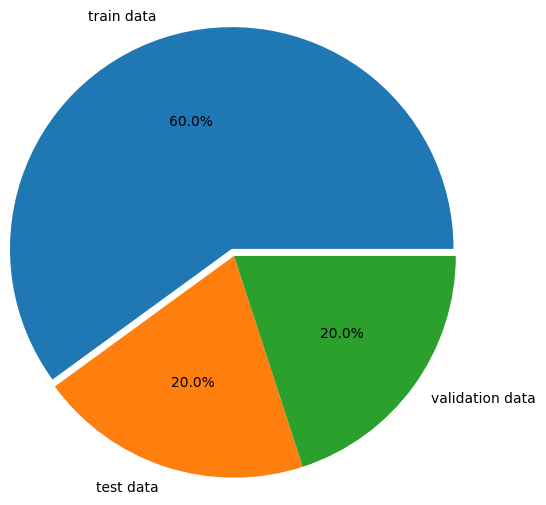

In [6]:
count_data = [len(train_dataset),len(test_dataset),len(val_dataset)]
plt.pie(x=count_data,labels=["train data","test data","validation data"],
        radius=1.5,autopct="%0.01f%%",explode=[0.05,0,0])
plt.show()

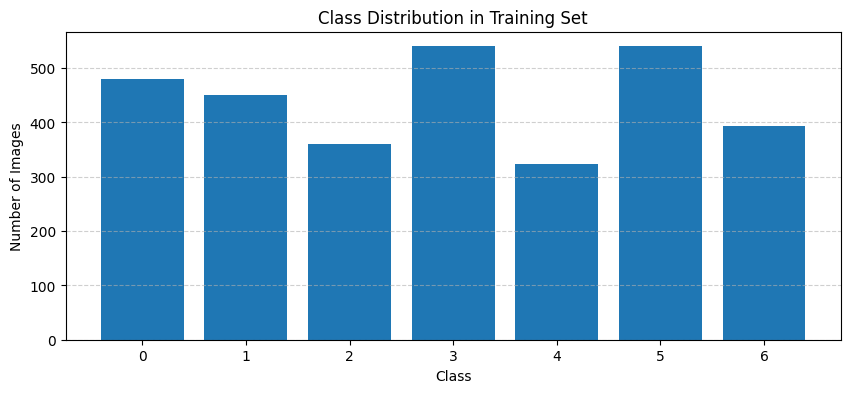

In [8]:
label_counts = Counter(train_dataset.targets)
plt.figure(figsize=(10, 4))
plt.bar(label_counts.keys(), label_counts.values())
plt.title('Class Distribution in Training Set')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.show()

0


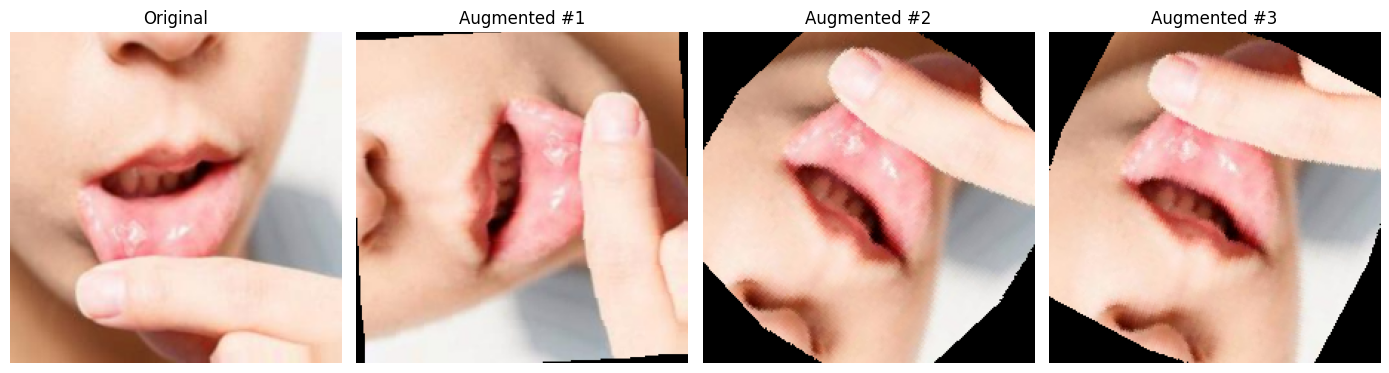

1


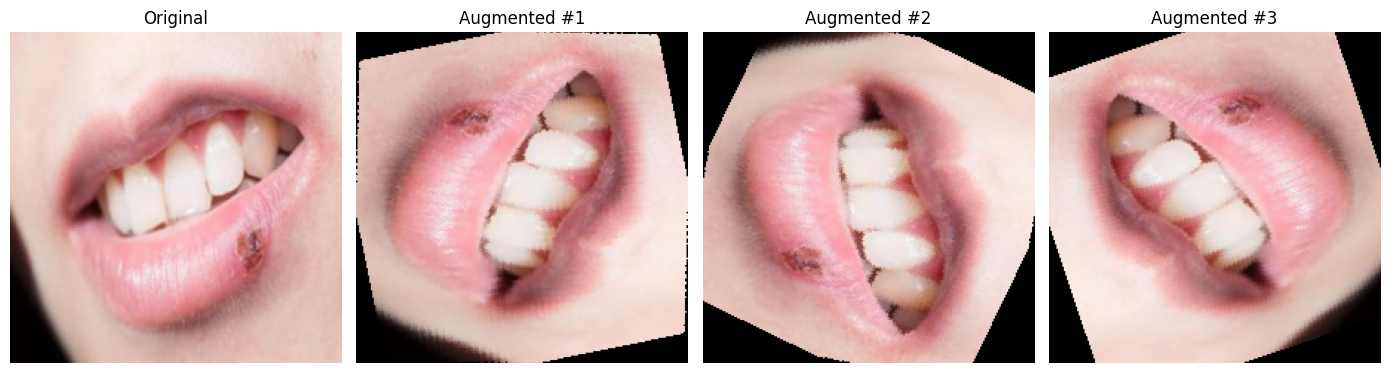

2


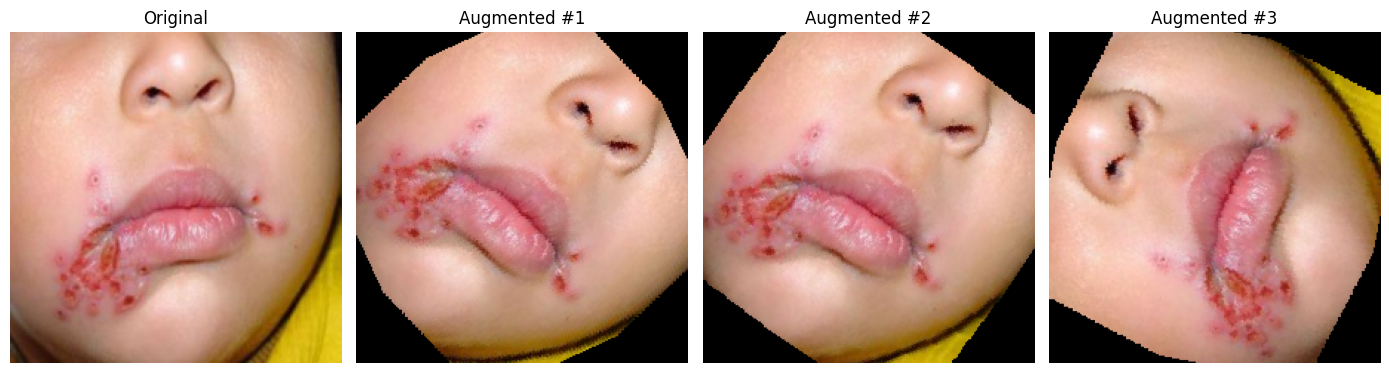

3


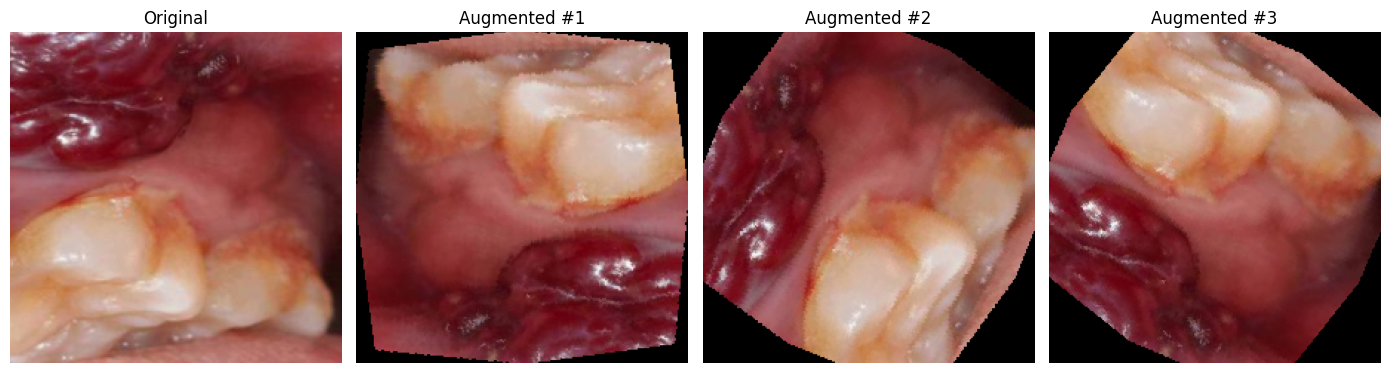

4


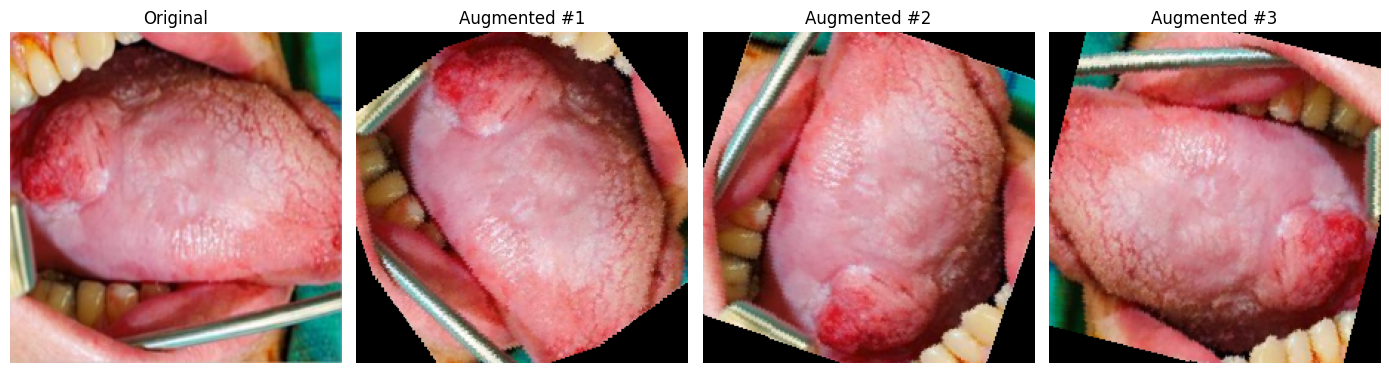

5


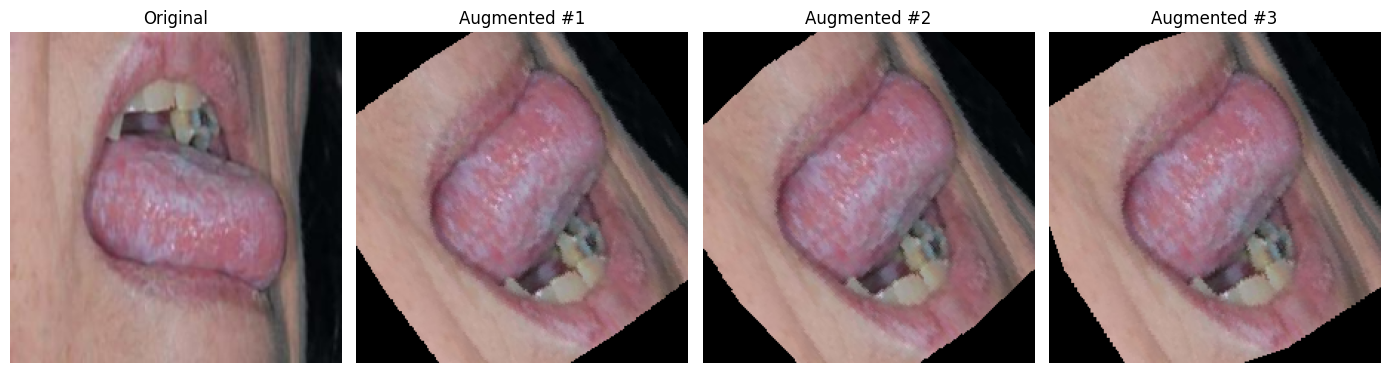

6


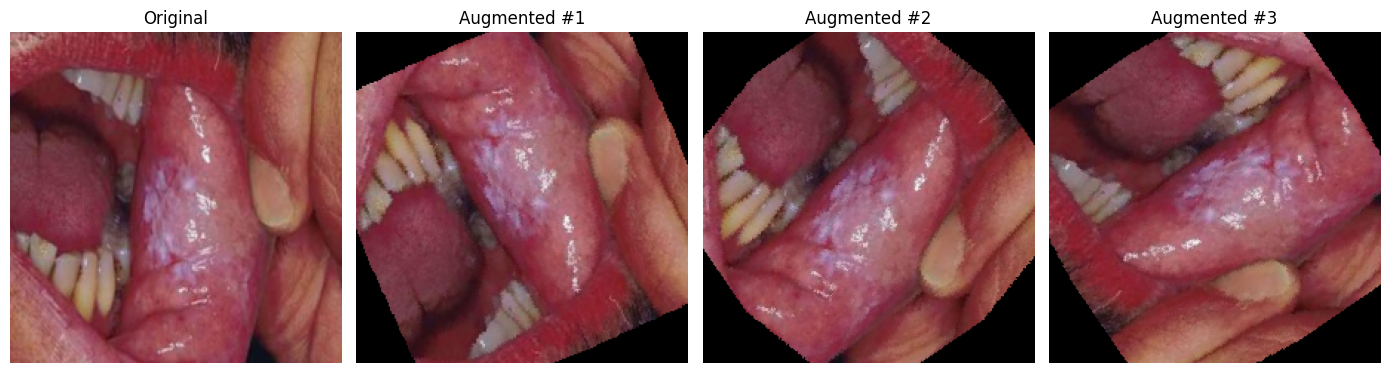

In [9]:
seen_classes = set()
class_images = {}

for img, label in train_dataset:
    if label not in seen_classes:
        class_images[label] = img
        seen_classes.add(label)
    if len(seen_classes) == 7:
        break

for label, img in class_images.items():
    unNormalized_augment_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Resize((224,224)),
    transforms.RandomRotation(20),
    transforms.RandomRotation(90),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomVerticalFlip(p=0.3)
])

    print(label)
    fig, axes = plt.subplots(1, 4, figsize=(14, 4))

    axes[0].imshow(img.permute(1, 2, 0).numpy())

    axes[0].set_title("Original")
    axes[0].axis('off')

    for i in range(1, 4):
        aug = unNormalized_augment_transform(img).permute(1, 2, 0).numpy()  # After .ToTensor this is the shape (C, H, W).
                                                                   # While this is the shape (H, W, C) imshow can handle so permute is needed tp reorder
        axes[i].imshow(aug)
        axes[i].set_title(f"Augmented #{i}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()


In [6]:
augment_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224,224)),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
    transforms.RandomRotation(20),
    transforms.RandomRotation(90),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomVerticalFlip(p=0.3)
])
normal_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])

])

train_dataset = datasets.ImageFolder(root=train_dataset_path,transform=augment_transform)
val_dataset = datasets.ImageFolder(root=val_dataset_path,transform=normal_transform)
test_dataset = datasets.ImageFolder(root=test_dataset_path,transform=normal_transform)

In [7]:
train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=100, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False)

In [12]:
class DenseLayer(nn.Module):
    def __init__(self, in_channels, growth_rate):
        super(DenseLayer, self).__init__()
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.relu1 = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_channels, 4 * growth_rate, kernel_size=1, stride=1, padding=0, bias=False)
        self.bn2 = nn.BatchNorm2d(4 * growth_rate)
        self.relu2 = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(4 * growth_rate, growth_rate, kernel_size=3, stride=1, padding=1, bias=False)
    def forward(self, x):
        identity = x 
        out = self.bn1(x)
        out = self.relu1(out)
        out = self.conv1(out)
        out = self.bn2(out)
        out = self.relu2(out)
        out = self.conv2(out)
        out = torch.cat([identity, out], dim=1)
        return out
class DenseBlock(nn.Module):
    def __init__(self, num_layers, in_channels, growth_rate):
        super(DenseBlock, self).__init__()
        layers = []
        for i in range(num_layers):
            layers.append(DenseLayer(in_channels + i * growth_rate, growth_rate))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)
class TransitionLayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(TransitionLayer, self).__init__()
        self.bn = nn.BatchNorm2d(in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0, bias=False)
        self.avg_pool = nn.AvgPool2d(kernel_size=2, stride=2)
    def forward(self, x):
        x = self.bn(x)
        x = self.relu(x)
        x = self.conv(x)
        x = self.avg_pool(x)
        return x
class DenseNet169(nn.Module):
    def __init__(self, num_classes=1000, growth_rate=32):
        super(DenseNet169, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        num_layers_per_block = [6, 12, 32, 32]
        in_channels = 64  
        self.dense1 = DenseBlock(num_layers_per_block[0], in_channels, growth_rate)
        in_channels += num_layers_per_block[0] * growth_rate
        self.trans1 = TransitionLayer(in_channels, in_channels // 2)
        in_channels //= 2
        self.dense2 = DenseBlock(num_layers_per_block[1], in_channels, growth_rate)
        in_channels += num_layers_per_block[1] * growth_rate
        self.trans2 = TransitionLayer(in_channels, in_channels // 2)
        in_channels //= 2
        self.dense3 = DenseBlock(num_layers_per_block[2], in_channels, growth_rate)
        in_channels += num_layers_per_block[2] * growth_rate
        self.trans3 = TransitionLayer(in_channels, in_channels // 2)
        in_channels //= 2
        self.dense4 = DenseBlock(num_layers_per_block[3], in_channels, growth_rate)
        in_channels += num_layers_per_block[3] * growth_rate
        self.bn_final = nn.BatchNorm2d(in_channels)
        self.relu_final = nn.ReLU(inplace=True)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(in_channels, num_classes)
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.dense1(x)
        x = self.trans1(x)
        x = self.dense2(x)
        x = self.trans2(x)
        x = self.dense3(x)
        x = self.trans3(x)
        x = self.dense4(x)
        x = self.bn_final(x)
        x = self.relu_final(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

In [8]:
def plot_metrics(train_loss, val_loss, train_acc, val_acc):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_loss, label='Train Loss')
    plt.plot(val_loss, label='Val Loss')
    plt.legend()
    plt.title('Loss over Epochs')

    plt.subplot(1, 2, 2)
    plt.plot(train_acc, label='Train Accuracy')
    plt.plot(val_acc, label='Val Accuracy')
    plt.legend()
    plt.title('Accuracy over Epochs')
    plt.show()

In [9]:
def train_model(model, train_loader, val_loader, lr, epochs):
    LCE = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []
    best_val_acc = 0.0


    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, total = 0.0, 0, 0

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            output = model(x_batch)
            loss = LCE(output, y_batch)
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(output, 1)
            train_correct += (predicted == y_batch).sum().item()
            train_loss += loss.item() * x_batch.size(0)
            total += y_batch.size(0)

        train_loss /= total
        train_correct /= total
        train_losses.append(train_loss)
        train_accuracies.append(train_correct)

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                loss = LCE(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_losses.append(val_loss / val_total)
        val_accuracies.append(val_correct / val_total)
        if val_correct / val_total > best_val_acc:
            best_val_acc = val_correct / val_total
            torch.save(model.state_dict(), "/kaggle/working/best_model.pth")
        print(f"Epoch {epoch+1}/{epochs}, "
              f"Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accuracies[-1]:.4f}, "
              f"Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_accuracies[-1]:.4f}")

    print("\n")
    return train_losses, val_losses, train_accuracies, val_accuracies


Epoch 1/32, Train Loss: 1.6331, Train Acc: 0.3534, Val Loss: 2.1235, Val Acc: 0.2140
Epoch 2/32, Train Loss: 1.3160, Train Acc: 0.5002, Val Loss: 1.4621, Val Acc: 0.4183
Epoch 3/32, Train Loss: 1.1673, Train Acc: 0.5692, Val Loss: 1.1641, Val Acc: 0.5506
Epoch 4/32, Train Loss: 1.0181, Train Acc: 0.6330, Val Loss: 0.9524, Val Acc: 0.6605
Epoch 5/32, Train Loss: 0.8665, Train Acc: 0.6761, Val Loss: 0.9199, Val Acc: 0.6644
Epoch 6/32, Train Loss: 0.7360, Train Acc: 0.7379, Val Loss: 0.8353, Val Acc: 0.6965
Epoch 7/32, Train Loss: 0.6473, Train Acc: 0.7736, Val Loss: 0.7621, Val Acc: 0.7442
Epoch 8/32, Train Loss: 0.5651, Train Acc: 0.8121, Val Loss: 0.7913, Val Acc: 0.7053
Epoch 9/32, Train Loss: 0.4806, Train Acc: 0.8361, Val Loss: 0.5116, Val Acc: 0.8220
Epoch 10/32, Train Loss: 0.4129, Train Acc: 0.8607, Val Loss: 0.5349, Val Acc: 0.8278
Epoch 11/32, Train Loss: 0.4052, Train Acc: 0.8607, Val Loss: 0.8262, Val Acc: 0.7412
Epoch 12/32, Train Loss: 0.3631, Train Acc: 0.8795, Val Loss: 0

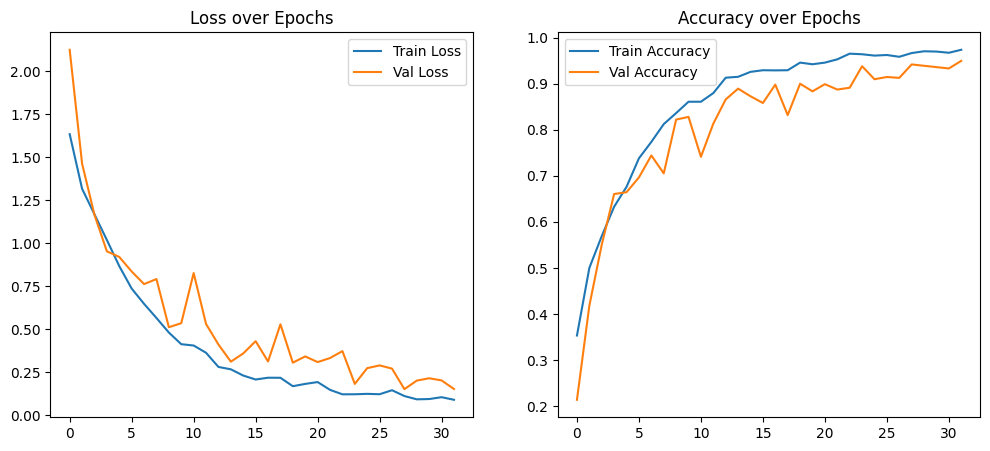

In [23]:
model = DenseNet169(num_classes=7).to(device)
train_loss, val_loss, train_acc, val_acc = train_model(model, train_loader, val_loader, 0.0001, epochs=32)
plot_metrics(train_loss, val_loss, train_acc, val_acc)

In [10]:
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total


In [25]:
model.load_state_dict(torch.load("/kaggle/working/best_model.pth"))

<All keys matched successfully>

In [26]:
test_acc = evaluate(model, test_loader)
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.9523


# Transfer Learning

In [11]:
model = models.densenet169(pretrained=False)
model.load_state_dict(torch.load("/kaggle/input/transfer-densenet-weights/densenet169-imagenet1k-v1.pth"))

layer_counter = 0
for name, param in model.named_parameters():
    layer_counter += 1
    if layer_counter <= 130:
        param.requires_grad = False
    else:
        param.requires_grad = True

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [12]:
num_features = model.classifier.in_features
model.classifier = nn.Linear(num_features, 7)
model = model.to(device)


Epoch 1/16, Train Loss: 1.3007, Train Acc: 0.5659, Val Loss: 0.9498, Val Acc: 0.6839
Epoch 2/16, Train Loss: 0.6254, Train Acc: 0.8160, Val Loss: 0.4724, Val Acc: 0.8833
Epoch 3/16, Train Loss: 0.3054, Train Acc: 0.9242, Val Loss: 0.3049, Val Acc: 0.9173
Epoch 4/16, Train Loss: 0.1544, Train Acc: 0.9637, Val Loss: 0.1665, Val Acc: 0.9582
Epoch 5/16, Train Loss: 0.0942, Train Acc: 0.9770, Val Loss: 0.1193, Val Acc: 0.9718
Epoch 6/16, Train Loss: 0.0690, Train Acc: 0.9825, Val Loss: 0.0781, Val Acc: 0.9796
Epoch 7/16, Train Loss: 0.0533, Train Acc: 0.9877, Val Loss: 0.0758, Val Acc: 0.9844
Epoch 8/16, Train Loss: 0.0403, Train Acc: 0.9913, Val Loss: 0.0522, Val Acc: 0.9844
Epoch 9/16, Train Loss: 0.0359, Train Acc: 0.9896, Val Loss: 0.0502, Val Acc: 0.9883
Epoch 10/16, Train Loss: 0.0359, Train Acc: 0.9887, Val Loss: 0.0562, Val Acc: 0.9825
Epoch 11/16, Train Loss: 0.0304, Train Acc: 0.9916, Val Loss: 0.0485, Val Acc: 0.9874
Epoch 12/16, Train Loss: 0.0242, Train Acc: 0.9938, Val Loss: 0

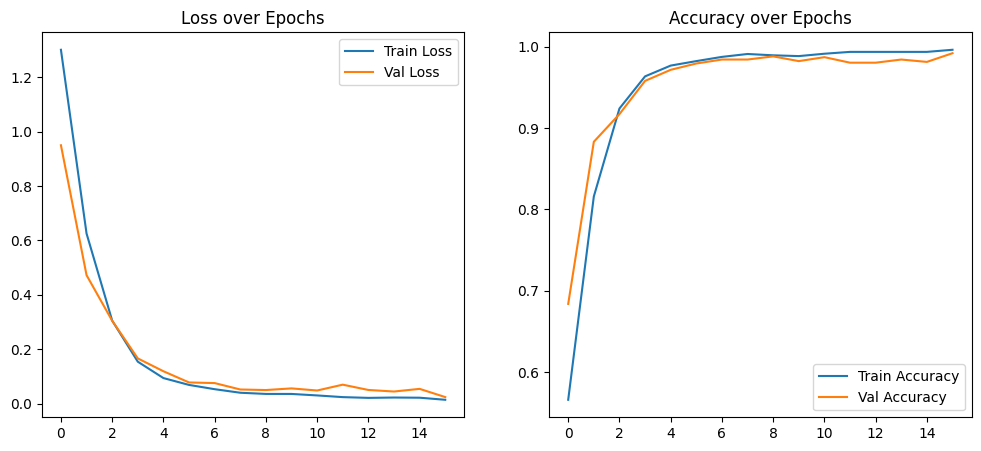

In [13]:
train_loss, val_loss, train_acc, val_acc = train_model(model, train_loader, val_loader, 0.0001, epochs=16)
plot_metrics(train_loss, val_loss, train_acc, val_acc)

In [14]:
model.load_state_dict(torch.load("/kaggle/working/best_model.pth"))

<All keys matched successfully>

In [15]:
test_acc = evaluate(model, test_loader)
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.9942
